### `phis_contour.ipynb` 
*Created: September 22, 2026* <br/>
This notebook implements the first four phi-functions ($\phi_0,\ldots,\phi_3$) directly from their definitions. 

In [72]:
using LinearAlgebra, NBInclude

In [64]:
#The first four Phi functions
φ₀(z) = exp(z)
φ₁(z) = expm1(z) / z 
φ₂(z) = (expm1(z) - z) / z^2 
φ₃(z) = (expm1(z) - z - z^2/2) / z^3

#=**Note:** 
    These functions are only intended for evaluating complex integrands in the contour integration formulas;
    they should NOT be considered reliable functions in their own right. 
=#

φ₃ (generic function with 1 method)

In [113]:
function phi_contour(λ::Float64, k::Int; M::Int = 64)
    """
    TODO: Test accuracy of phi_contour by comparing against a high precision reference implementation. 
    If the relative error is very small, then that means `phi_contour` is trustworthy. 
    
    Compute φₖ(λ) using contour integration. The sample points are evaluated using the direct formulas given above.
    
    PARAMETERS
    ----------
    λ :: real number at which to evaluate the phi function
    k :: the phi function subscript
    M :: number of quadrature nodes 
    """

    #Note: For a real argument lambda, we can leverage symmetry and just integrate over the upper semi-circle. 
    #"If this symmetry is not explicitly used in the computation of the ϕ-functions when λ is real, rounding
    #errors appear that lead to numerical instability." - Montanelli & Bootland, 2016. 

    M > 0 || throw(ArgumentError("M must be positive."))
    
    #angles of the quadrature points 
    θ = (π/M) .* (0.5:1.0:(M-0.5))

    #radius of contour circle 
    r = 1.0 

    #Contour points
    z = λ .+ r .* exp.(im .* θ)

    if k == 0 
        return real(sum(φ₀.(z)) / M)
    elseif k == 1 
        return real(sum(φ₁.(z)) / M)
    elseif k == 2 
        return real(sum(φ₂.(z)) / M)
    elseif k == 3 
        return real(sum(φ₃.(z)) / M)
    else
        throw(ArgumentError("k must be 0,1,2 or 3."))
    end 
end

phi_contour (generic function with 3 methods)

In [ ]:
function phi_contour_high_precision(λ::Float64, k::Int; M::Int = 64, precision::Int = 256)
    """
  
    PARAMETERS
    ----------
    λ :: real number at which to evaluate the phi function
    k :: the phi function subscript
    M :: number of quadrature nodes 
    precision :: number of digits of the significant for the BigFloat arithmetic 
    """

    M > 0 || throw(ArgumentError("M must be positive."))



    
    #angles of the quadrature points 
    θ = (π/M) .* (0.5:1.0:(M-0.5))

    #radius of contour circle 
    r = 1.0 

    #Contour points
    z = λ .+ r .* exp.(im .* θ)

    if k == 0 
        return real(sum(φ₀.(z)) / M)
    elseif k == 1 
        return real(sum(φ₁.(z)) / M)
    elseif k == 2 
        return real(sum(φ₂.(z)) / M)
    elseif k == 3 
        return real(sum(φ₃.(z)) / M)
    else
        throw(ArgumentError("k must be 0,1,2 or 3."))
    end 
end

In [109]:
function phi_contour(B::Diagonal{Float64}, k::Int; M::Int = 64)

    #Compute ϕₖ(B), where B is a digonal matrix 
    M > 0 || throw(ArgumentError("M must be positive."))
    0 ≤ k ≤ 3 || throw(ArgumentError("k must be 0,1,2, or 3."))
    
    phis = phi_contour.(B.diag, k; M)
    return Diagonal(phis)
end 

phi_contour (generic function with 3 methods)

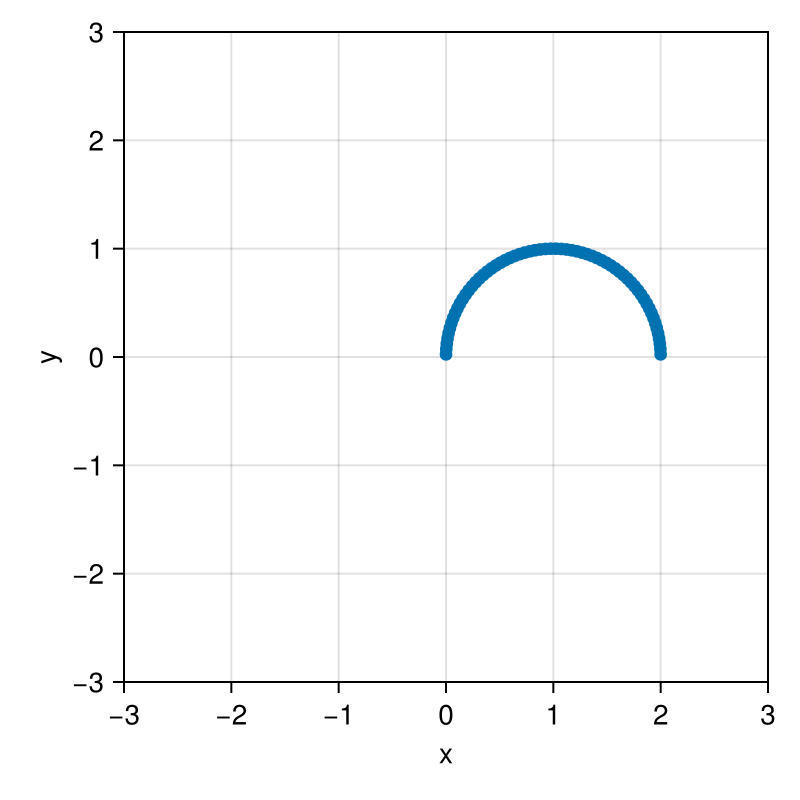

CairoMakie.Screen{IMAGE}


In [56]:
##Visualize the contour integration nodes 
# using CairoMakie
# fig = Figure(size = (400,400))
# ax = Axis(fig[1,1], xlabel = "x", ylabel = "y", limits = (-3,3,-3,3))
# scatter!(ax, real.(pts), imag.(pts))
# display(fig)